# Gene level evaluation

In [1]:
import pandas as pd
from pathlib import Path
import os

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc

import InterScale as interscale
from InterScale._paths import FIG_PATH
from InterScale.config import load_config

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pi

## 0. Load paths

In [2]:
BASE_DIR_PROJECT = "/lustre/groups/ml01/workspace/sara.jimenez/InterScale/"
CFG_DUAL_LEGNINI = os.path.join(BASE_DIR_PROJECT, "configs/legnini23_regr_node_DualCombined_genes.yaml")
RESULTS_DIR = os.path.join(BASE_DIR_PROJECT, "results")

## 1. Load trained model

In [3]:
import random
import numpy as np
import torch

def set_full_reproducibility(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_full_reproducibility(42)

In [4]:
cfg = load_config(CFG_DUAL_LEGNINI)
cfg

CfgNode({'wandb': CfgNode({'use': False, 'project_name': 'GTLongRange_Legnini23'}), 'model': CfgNode({'n_embed': 16, 'local_component': CfgNode({'name': 'GCN', 'parameters': CfgNode({'hidden_dim': 256, 'num_layers': 2, 'dropout_local': 0.1})}), 'global_component': CfgNode({'name': 'self-attn-transformer', 'parameters': CfgNode({'n_heads': 4, 'dim_feedforward': 256, 'dropout_global': 0.1, 'activation_func': 'relu', 'num_layers': 2, 'max_seq_len': 4299, 'long_range_attention': False, 'type_gex_embedding': None}), 'latent_obsm_key': None}), 'save': None, 'loss': None, 'decoder': CfgNode({'type': 'linear', 'hidden_dims': [256, 128], 'dropout_decoder': 0.1, 'dual_decoder': True})}), 'optim': CfgNode({'accelerator': 'cpu', 'lr': 0.001, 'lr_scheduler': 'CosineWarmupScheduler', 'lr_warmup': 20, 'lr_max_epochs': 100, 'wd': 0.0001, 'loss': 'SmoothL1', 'seed': 44, 'cross_corr': 'cell', 'n_epochs': 100, 'early_stopping': True}), 'dataset': CfgNode({'h5ad_data': '/lustre/groups/ml01/projects/2024_s

In [5]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

In [6]:
import numpy as np
zero_expression_cells = np.array((adata.X.sum(axis=1) == 0)).flatten()
print(f"Nr. of zero expression cells: {zero_expression_cells.sum()}")
nonzero_cells = np.array((adata.X.sum(axis=1) != 0)).flatten()
adata = adata[nonzero_cells].copy()

Nr. of zero expression cells: 648


In [7]:
model_name = "legnini23/model_dual_decoder/dual_legnini23_regr_node_44_GCN_self-attn-transformer_model"

In [8]:
interscale.model.CombinedModel._setup_anndata(
    adata = adata, 
    prediction_task = cfg.dataset.prediction_task, 
    layer_key = cfg.dataset.layer_key, 
    sample_key_list = cfg.dataset.sample_key, 
    prediction_obs =  cfg.dataset.prediction_obs, 
    group_key = cfg.dataset.group_label, 
    view_registry = False
)

dual_combined_model = interscale.model.CombinedModel.load(
    os.path.join(RESULTS_DIR, "legnini23/model_dual_decoder"), 
    adata, 
    cfg,
    model_name="dual_legnini23_regr_node_44_GCN_self-attn-transformer_model",
    local_component = True, 
    global_component = True, 
)

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Loading model from /lustre/groups/ml01/workspace/sara.jimenez/InterScale/results/legnini23/model_dual_decoder/dual_legnini23_regr_node_44_GCN_self-attn-transformer_modelmodel.pt
Try with .ckpt extension.
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


In [9]:
print(dual_combined_model)

## 2. Gene level evaluation

In [10]:
result = dual_combined_model.get_model_output(adata)

Load GEX from .layers/log1p_norm


In [11]:
result

AnnData object with n_obs × n_vars = 43114 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_label', '_cls_horizontal', '_cls_vertical'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', '_local_emb', '_global_emb', '_attn_matrix'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', '_y_pred_local', '_y_pred_global'

### Clustering of the embeddings

In [13]:
clustering_slide = result[result.obs['sample'] == 'slide4_B2-2'].copy()

clustering_slide_local = clustering_slide.copy()
clustering_slide_global = clustering_slide.copy()

sc.pp.neighbors(clustering_slide_local, use_rep='_local_emb')
sc.pp.neighbors(clustering_slide_global, use_rep='_global_emb')

sc.tl.leiden(clustering_slide_local, resolution=0.7)
sc.tl.leiden(clustering_slide_global, resolution=0.7)

/tmp/ipykernel_3438999/4073801033.py:9: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(clustering_slide_local, resolution=0.7)


/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


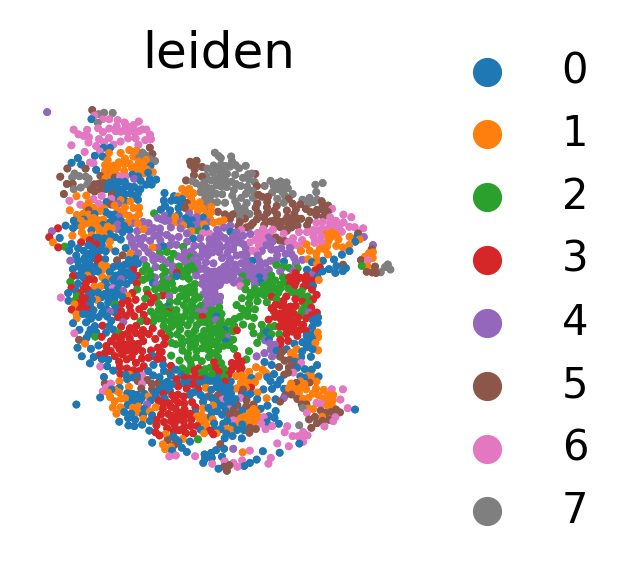

In [21]:
import squidpy as sq

sq.pl.spatial_scatter(clustering_slide_local, 
                      library_key='sample',
                      library_id=['slide4_B2-2'],
                      color = 'leiden',
                      ncols=1,
                      shape= None,
                      frameon=False,
                      dpi=300,
                      figsize=(2, 2),
                      size=3,
                      save='local_emb_clustering.png',
                     )

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


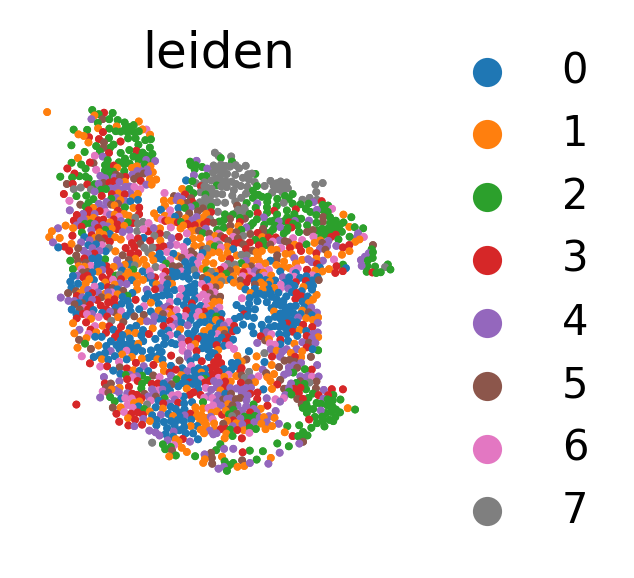

In [22]:
sq.pl.spatial_scatter(clustering_slide_global, 
                      library_key='sample',
                      library_id=['slide4_B2-2'],
                      color = 'leiden',
                      ncols=1,
                      shape= None,
                      frameon=False,
                      dpi=300,
                      figsize=(2, 2),
                      size=3,
                      save='global_emb_clustering.png',
                     )

### Gene loadings analysis

standardize gene loadings meaning = change in gene g (in gene SD units) per 1 SD increase in latent dimension k.

In [12]:
from InterScale.evaluation import gene_loadings

In [13]:
gene_loadings(
    result,
    dual_combined_model,
    local_latent_key = "_global_emb",
    global_latent_key = "_global_emb",
    layer_key="log1p_norm",
)

AnnData object with n_obs × n_vars = 43114 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_label', '_cls_horizontal', '_cls_vertical'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', '_local_emb', '_global_emb', '_attn_matrix'
    varm: '_local_std_gene_loadings', '_global_std_gene_loadings'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', '_y_pred_local', '_y_pred_global'

In [83]:
# Define multiple gene sets
gene_set = ["SHH","NKX2.2","NKX6.1","PAX6","OLIG2","IRX3","DBX2"]

### Covariance analysis of embedding dimensions based on gene loadings

In [ ]:
shh_test = result[result.obs['sample'] == 'slide4_B2-2']
ctrl_test = result[result.obs['sample'] == 'slide4_A2-3']

#### 1. Are the embedding dimensions linearly independent?

For the local and global embeddings separately: 

- Linear independence of embedding dimensions = columns of Z are linearly independent, i.e. rank(Z) == n_dims
- Visual: Plot the correlation between each embedding dimension. If the matrix is almost diagonal, we can assume linea independence. 

In [15]:
from InterScale.evaluation import latent_rank_report, pl_latent_correlation

In [16]:
# Check rank:
rep_global = latent_rank_report(result, "_global_emb")
rep_local  = latent_rank_report(result, "_local_emb")
print(rep_global)
print(rep_local)

{'z_key': '_global_emb', 'n_obs': 43114, 'n_dims': 16, 'rank': 16, 'linearly_independent': True}
{'z_key': '_local_emb', 'n_obs': 43114, 'n_dims': 16, 'rank': 16, 'linearly_independent': True}


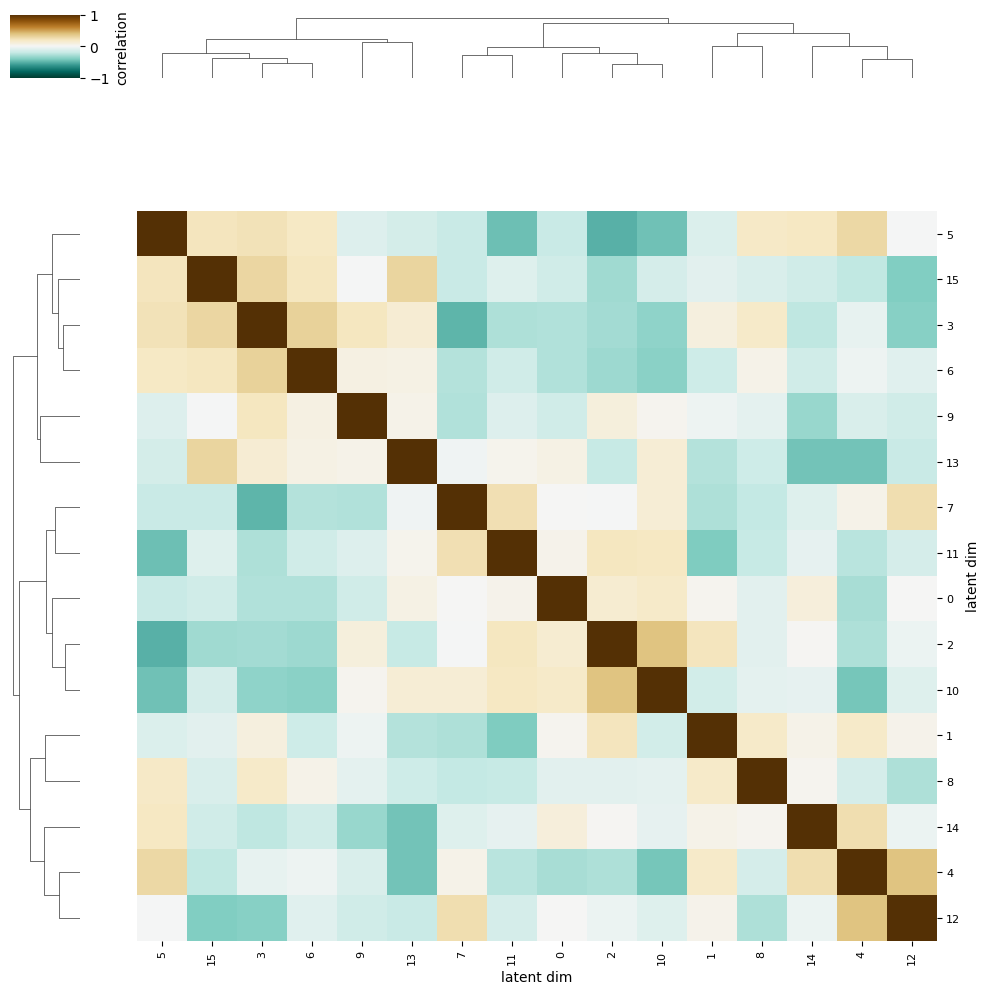

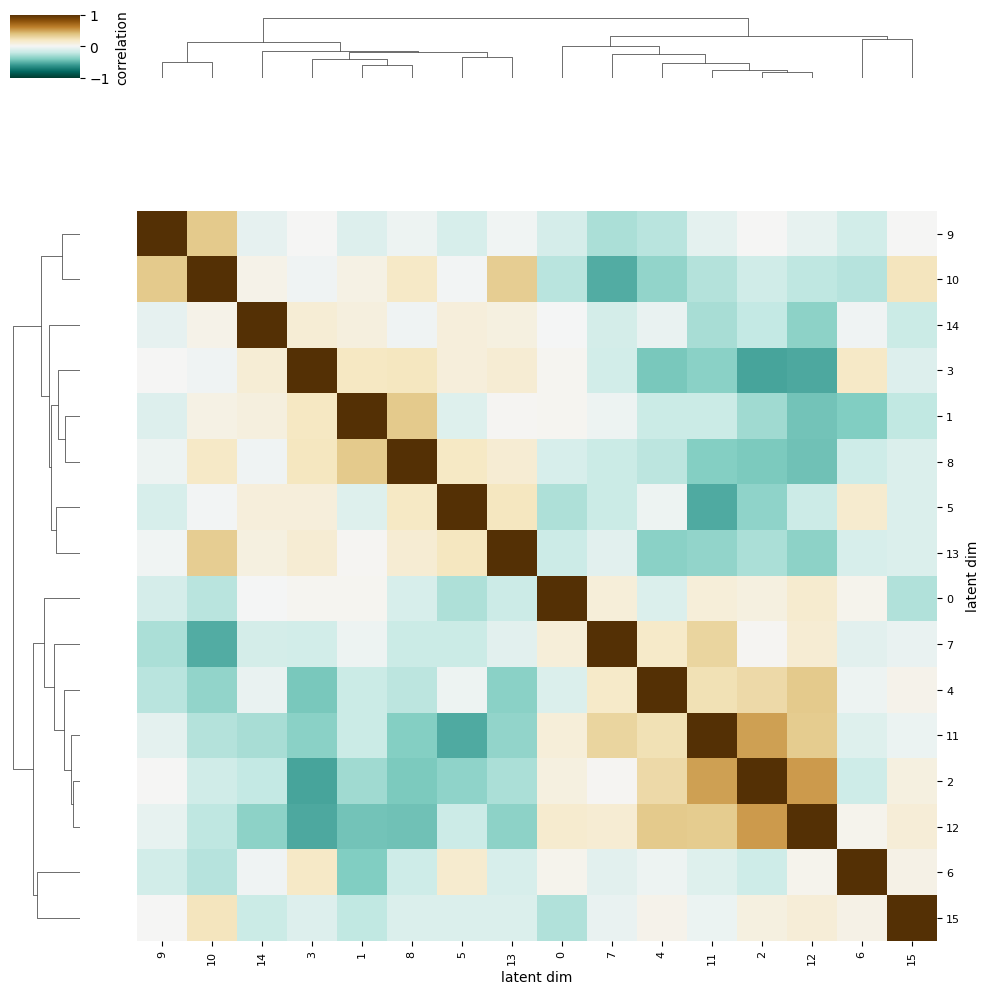

In [17]:
# Visual Pearson correlation beteween embedding dimensions

pl_latent_correlation(result, z_key="_local_emb", vmax=1.0, cmap="BrBG_r")
pl_latent_correlation(result, z_key="_global_emb", vmax=1.0, cmap="BrBG_r")

Text(929.4184027777777, 0.5, 'local latent dim')

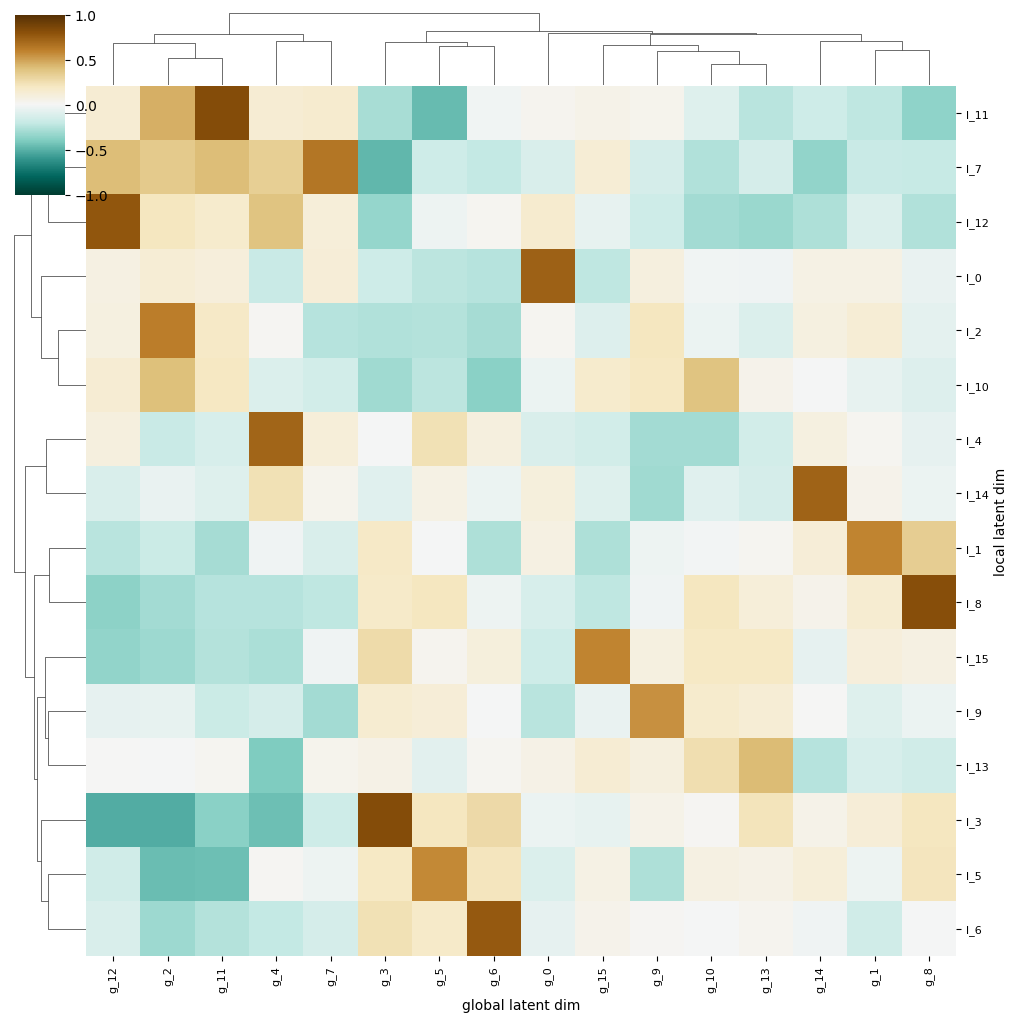

In [18]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Z_local = result.obsm["_local_emb"]
Z_global = result.obsm["_global_emb"]

# Standardize each dim across cells
Zl = (Z_local - Z_local.mean(axis=0)) / Z_local.std(axis=0, ddof=1)
Zg = (Z_global - Z_global.mean(axis=0)) / Z_global.std(axis=0, ddof=1)

# Cross-correlation: (L x N) @ (N x G) -> (L x G)
C = (Zl.T @ Zg) / (Zl.shape[0] - 1)

# Labels
row_labels = [f"l_{i}" for i in range(C.shape[0])]
col_labels = [f"g_{j}" for j in range(C.shape[1])]

g = sns.clustermap(
    C,
    dendrogram_ratio=(0.08, 0.08),
    cmap="BrBG_r",
    vmin=-1.0,
    vmax=1.0,
    figsize=(10, 10),
    method="average",
    metric="euclidean",
    xticklabels=col_labels,
    yticklabels=row_labels,
    z_score=None,
    standard_scale=None,
    #cbar_kws={"label": "corr"},
)

# Rotate and resize tick labels
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=90,
    fontsize=8
)

g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    rotation=0,
    fontsize=8
)

g.ax_heatmap.set_xlabel("global latent dim")
g.ax_heatmap.set_ylabel("local latent dim")

#### 2. Per-dimension contribution to variance of reconstructed gene expression

Because we're using a linear decoder and we have uncorrelated embedding dimensions then: 

```Var(Ŷ) ~ tr((W^TW)Cov(H))```

In [19]:
from InterScale.evaluation import pl_dim_importance_elbow_stdexpr, get_genes_dim


60% cumulative variance reached with 5 dimensions:
Embedding dimensions (sorted by importance):
[11, 1, 7, 5, 10]


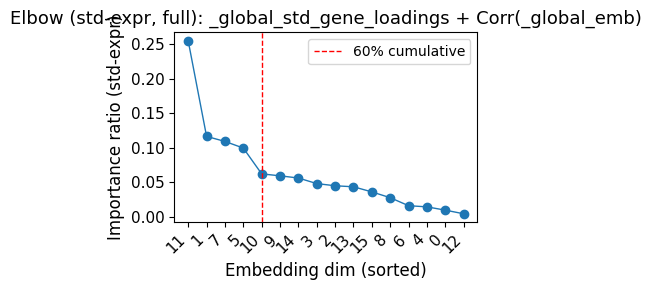

<Axes: title={'center': 'Elbow (std-expr, full): _global_std_gene_loadings + Corr(_global_emb)'}, xlabel='Embedding dim (sorted)', ylabel='Importance ratio (std-expr)'>

In [213]:
pl_dim_importance_elbow_stdexpr(
    result,
    s_key="_global_std_gene_loadings",
    z_key="_global_emb",
    mode="full",               # "full" (uses Corr(Z) off-diagonals) or "diag" (assumes dims uncorrelated)
    use_ratio=True,              # True -> normalize to sum to 1 (if total>0)
    cumulative_cutoff=0.60,      # vertical line at smallest #dims reaching cutoff (only meaningful if use_ratio and total>0)
    spacing=1,
    figsize=(4,3),
    fontsize=12,
    title=None,
    show=True,
)

In [20]:
ax.figure.savefig("figures/elbow_global.png", dpi=300, bbox_inches="tight")

NameError: name 'ax' is not defined


60% cumulative variance reached with 6 dimensions:
Embedding dimensions (sorted by importance):
[13, 14, 1, 0, 7, 2]


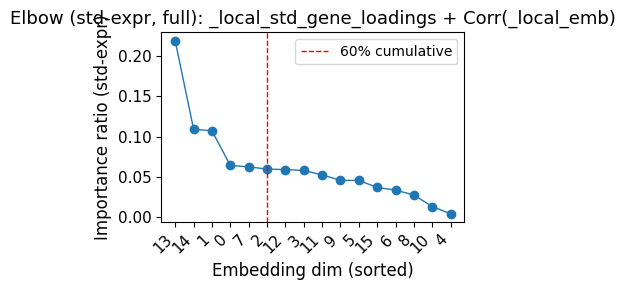

<Axes: title={'center': 'Elbow (std-expr, full): _local_std_gene_loadings + Corr(_local_emb)'}, xlabel='Embedding dim (sorted)', ylabel='Importance ratio (std-expr)'>

In [215]:
pl_dim_importance_elbow_stdexpr(
    result,
    s_key="_local_std_gene_loadings",
    z_key="_local_emb",
    mode="full",               # "full" (uses Corr(Z) off-diagonals) or "diag" (assumes dims uncorrelated)
    use_ratio=True,              # True -> normalize to sum to 1 (if total>0)
    cumulative_cutoff=0.60,      # vertical line at smallest #dims reaching cutoff (only meaningful if use_ratio and total>0)
    spacing=1,
    figsize=(4, 3),
    fontsize=12,
    title=None,
    show=True,
)

##### 3. Gene scoring 

standardize gene loadings meaning = change in gene g (in gene SD units) per 1 SD increase in latent dimension k.  

- Expression filtering:
| Argument   | Effect                               |
| ---------- | ------------------------------------ |
| `X_layer`  | Expression matrix used for filtering |
| `min_frac` | Remove rare genes                    |
| `min_sd`   | Remove low-variance genes            |

- Scoring choices
| Argument                 | Meaning                                |
| ------------------------ | -------------------------------------- |
| `rank_by="loading"`      | Pure decoder sensitivity               |
| `rank_by="loading_x_sd"` | Favor highly variable genes            |
| `residualize=True`       | Use only unique component of dimension |

- Specificity control
| Argument                   | Meaning                              |
| -------------------------- | ------------------------------------ |
| `enforce_specificity`      | Force genes to be dimension-specific |
| `specificity_mode="ratio"` | max/second criterion                 |
| `specificity_min`          | How strict the specificity must be   |

 
gene_by_dim_heatmap interpretation:

So:

Dark brown → strong positive association with that dimension

Dark green → strong negative association

Near white → little association

In [22]:
global_dim = [11, 1, 7, 5, 10]
local_dim = [13, 14, 1, 0, 7, 2]

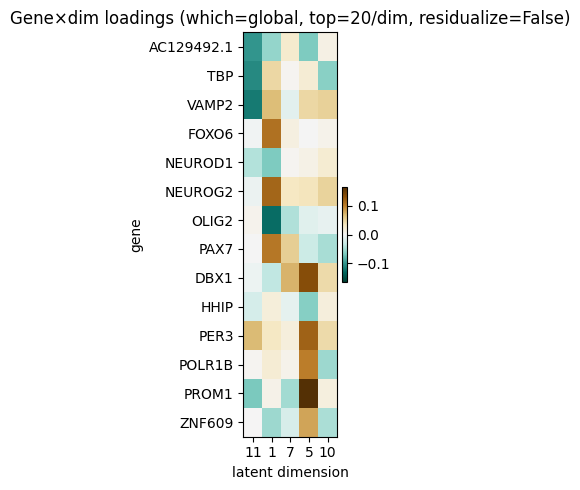

In [171]:
df_global, ax = get_genes_dim(
    result,
    which="global",
    dims=global_dim,
    n_top=20,
    X_layer="log1p_norm",
    min_frac=0.1,
    rank_by="loading_x_sd",
    enforce_specificity=True,
    specificity_min=1.5,
    #residualize=True,
    plot=True,
    figsize=(3, 5),
)

In [114]:
ax.figure.savefig("figures/global_genes_dim_plot.png", dpi=300, bbox_inches="tight")

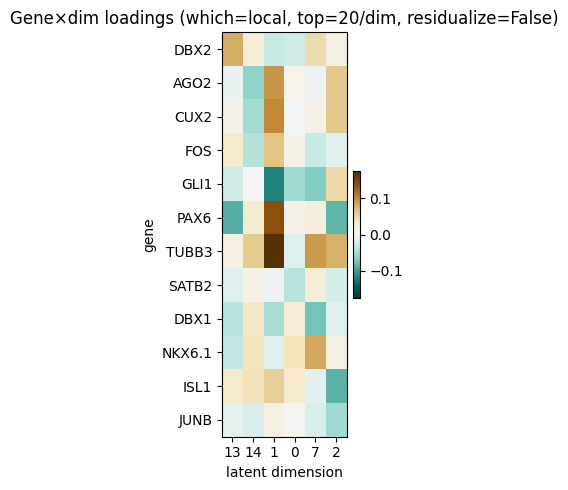

In [172]:
df_local, ax = get_genes_dim(
    result,
    which="local",
    dims=local_dim,
    n_top=20,
    X_layer="log1p_norm",
    min_frac=0.1,
    enforce_specificity=True,
    rank_by="loading_x_sd",
    specificity_min=1.5,
    #residualize=True,
    plot=True,
    figsize=(3, 5),
)

In [116]:
ax.figure.savefig("figures/local_genes_dim_plot.png", dpi=300, bbox_inches="tight")

In [173]:
global_genes = df_global.index 
local_genes = df_local.index

shared = global_genes.intersection(local_genes)
unique_local = local_genes.difference(global_genes)
unique_global = global_genes.difference(local_genes)

print("Shared:", shared.tolist())
print("Unique local:", unique_local.tolist())
print("Unique global:", unique_global.tolist())

Shared: ['DBX1']
Unique local: ['AGO2', 'CUX2', 'DBX2', 'FOS', 'GLI1', 'ISL1', 'JUNB', 'NKX6.1', 'PAX6', 'SATB2', 'TUBB3']
Unique global: ['AC129492.1', 'FOXO6', 'HHIP', 'NEUROD1', 'NEUROG2', 'OLIG2', 'PAX7', 'PER3', 'POLR1B', 'PROM1', 'TBP', 'VAMP2', 'ZNF609']


In [26]:
import squidpy as sq

In [27]:
result.X = result.layers['log1p_norm'].copy()

In [28]:
result.obs['z11_global'] = result.obsm['_global_emb'][:,11]
result.obs['z5_global'] = result.obsm['_global_emb'][:,5]
result.obs['z1_global'] = result.obsm['_global_emb'][:,1]
result.obs['z7_global'] = result.obsm['_global_emb'][:,7]
result.obs['z10_global'] = result.obsm['_global_emb'][:,10]

result.obs['z13_local'] = result.obsm['_local_emb'][:,13]
result.obs['z1_local'] = result.obsm['_local_emb'][:,1]
result.obs['z14_local'] = result.obsm['_local_emb'][:,14]
result.obs['z7_local'] = result.obsm['_local_emb'][:,7]
result.obs['z0_local'] = result.obsm['_local_emb'][:,0]
result.obs['z2_local'] = result.obsm['_local_emb'][:,2]

In [117]:
local_genes = ['CUX2','GLI1','TUBB3','ISL1']
global_genes =  ['FOXO6','NEUROG2','HHIP','PROM1']

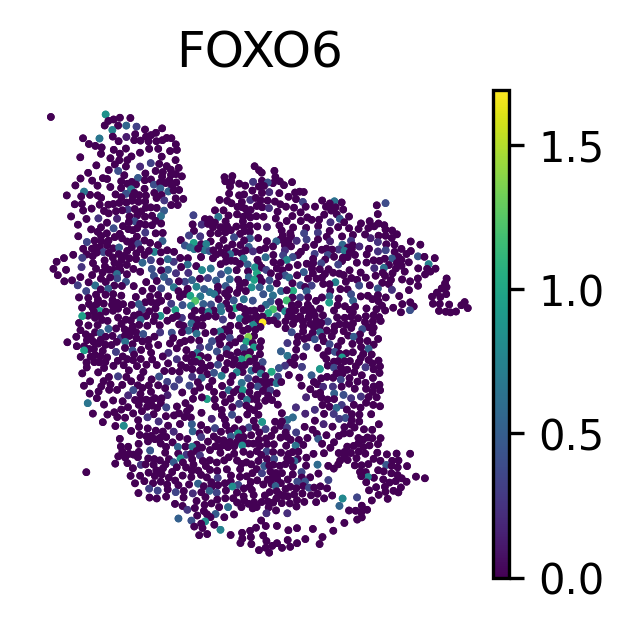

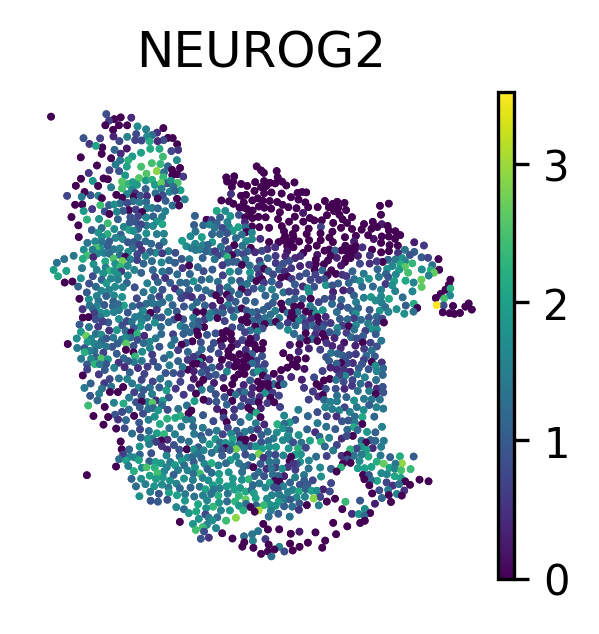

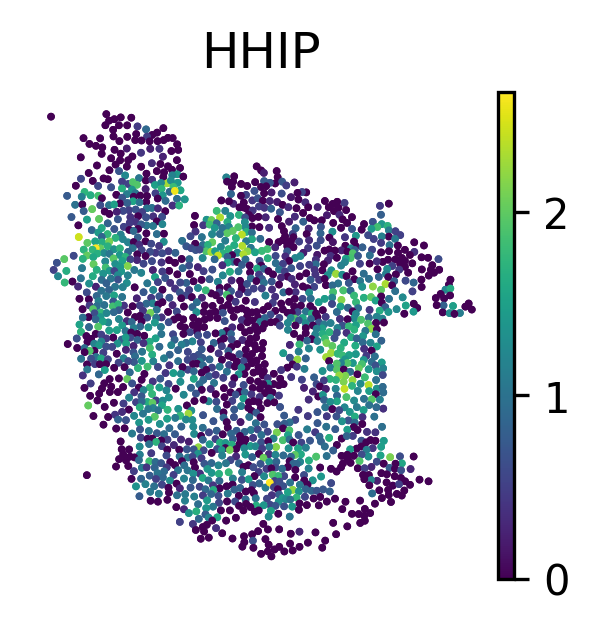

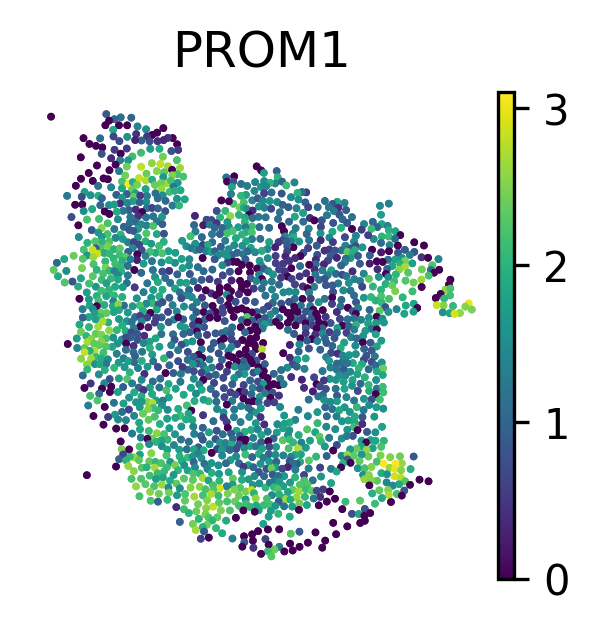

In [119]:
for gene in global_genes:
    sq.pl.spatial_scatter(result, 
                          library_key='sample',
                          library_id=['slide4_B2-2'],
                          color = gene,
                          cmap = 'viridis',
                          ncols=1,
                          shape= None, 
                          frameon=False,
                          dpi=300,
                          figsize=(2, 2),
                          save=f'{gene}_spatial_scatter.png',
                         )

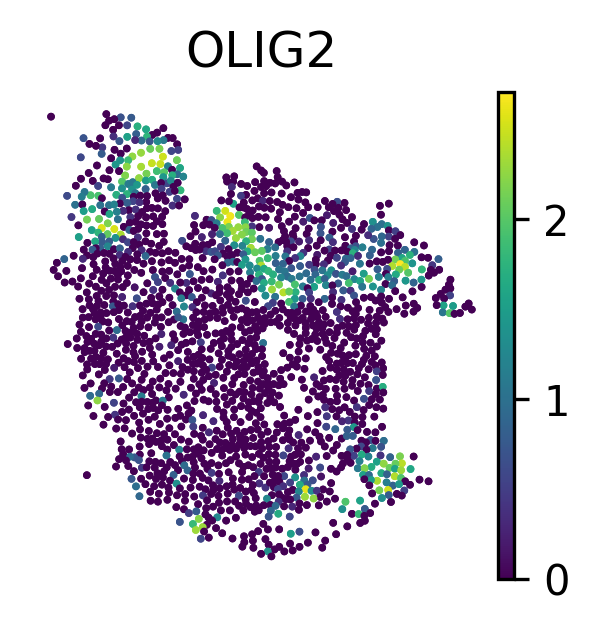

In [229]:
gene = 'OLIG2'
sq.pl.spatial_scatter(result, 
                          library_key='sample',
                          library_id=['slide4_B2-2'],
                          color = gene,
                          cmap = 'viridis',
                          ncols=1,
                          shape= None, 
                          frameon=False,
                          dpi=300,
                          figsize=(2, 2),
                          save=f'{gene}_spatial_scatter.png',
                         )

In [30]:
shh_test = result[result.obs['sample'] == 'slide4_B2-2'].copy()

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import squidpy as sq


def compute_knn_dependent_morans_i_gene(
    adata,
    genes,
    n_neighs=(8, 16, 32, 100),
    layer=None,
    use_raw=False,
    coord_type="generic",
    library_key=None,
    delaunay=False,
    n_perms=None,
    transformation=True,
    copy=False,
):
    """
    Compute Moran's I for one or multiple genes across multiple kNN graphs.

    Parameters
    ----------
    adata : AnnData
        AnnData object with spatial coordinates in adata.obsm["spatial"].
    genes : str or list[str]
        Gene name(s) to analyze.
    n_neighs : iterable[int]
        Numbers of neighbors used to build spatial graphs.
    layer : str or None
        Use adata.layers[layer] instead of adata.X.
    use_raw : bool
        Use adata.raw for expression.
    coord_type : str
        Coordinate type passed to squidpy.
    library_key : str or None
        Column in adata.obs identifying slide/FOV.
    delaunay : bool
        Whether to use Delaunay triangulation.
    n_perms : int or None
        Number of permutations.
    transformation : bool
        Row-normalize spatial weights.
    copy : bool
        Whether to work on a copy of adata.

    Returns
    -------
    moran_df : pd.DataFrame
        Long-format dataframe with rows for (gene, n_neigh).
    """

    if isinstance(genes, str):
        genes = [genes]

    if "spatial" not in adata.obsm:
        raise ValueError("adata.obsm['spatial'] is required.")

    if library_key is not None and library_key not in adata.obs:
        raise ValueError(f"{library_key!r} not found in adata.obs.")

    ad = adata.copy() if copy else adata

    obs_keys = []

    for gene in genes:

        if use_raw:
            if ad.raw is None:
                raise ValueError("use_raw=True but adata.raw is None.")
            if gene not in ad.raw.var_names:
                raise ValueError(f"{gene!r} not found in adata.raw.var_names.")
            x = ad.raw[:, gene].X

        elif layer is not None:
            if layer not in ad.layers:
                raise ValueError(f"{layer!r} not found in adata.layers.")
            if gene not in ad.var_names:
                raise ValueError(f"{gene!r} not found in adata.var_names.")
            x = ad[:, gene].layers[layer]

        else:
            if gene not in ad.var_names:
                raise ValueError(f"{gene!r} not found in adata.var_names.")
            x = ad[:, gene].X

        if hasattr(x, "toarray"):
            x = x.toarray()

        x = np.asarray(x).reshape(-1)

        obs_key = f"__moran_gene_{gene}"
        ad.obs[obs_key] = x
        obs_keys.append(obs_key)

    results = []

    for k in n_neighs:

        sq.gr.spatial_neighbors(
            ad,
            coord_type=coord_type,
            n_neighs=int(k),
            delaunay=delaunay,
            library_key=library_key,
        )

        sq.gr.spatial_autocorr(
            ad,
            mode="moran",
            genes=obs_keys,
            attr="obs",
            transformation=transformation,
            n_perms=n_perms,
        )

        df = ad.uns["moranI"].copy()
        #df = ad.uns["gearyC"].copy()
        

        df["gene"] = [key.replace("__moran_gene_", "") for key in df.index]
        df["n_neigh"] = int(k)

        A = ad.obsp["spatial_connectivities"]
        degree = np.asarray(A.sum(axis=1)).reshape(-1)

        df["mean_degree"] = degree.mean()
        df["min_degree"] = degree.min()
        df["max_degree"] = degree.max()

        results.append(df.reset_index(drop=True))

    moran_df = pd.concat(results, ignore_index=True)

    return moran_df

In [231]:
def plot_knn_dependent_morans_i_gene(
    moran_df,
    genes=None,
    value_col="I",
    figsize=(7,4),
    marker="o",
    save_path=None,
    dpi=300,
    fmt=None
):
    """
    Plot Moran's I vs number of neighbors for one or multiple genes.

    Parameters
    ----------
    moran_df : pandas.DataFrame
        Dataframe containing Moran's I results. Must include columns
        'gene', 'n_neigh', and value_col.

    genes : str or list[str], optional
        Subset of genes to plot.

    value_col : str
        Column containing Moran's I values.

    figsize : tuple
        Figure size.

    marker : str
        Matplotlib marker style.

    save_path : str or None
        If provided, saves the figure to this path.

    dpi : int
        DPI used when saving the figure.

    fmt : str or None
        Explicit format ("png", "svg", etc). If None, inferred from save_path.
    """

    import matplotlib.pyplot as plt
    import os

    if value_col not in moran_df.columns:
        raise ValueError(f"{value_col} not found in dataframe.")

    plot_df = moran_df.copy()

    if genes is not None:
        if isinstance(genes, str):
            genes = [genes]
        plot_df = plot_df[plot_df["gene"].isin(genes)]

    fig, ax = plt.subplots(figsize=figsize)

    for gene, sub in plot_df.groupby("gene"):

        sub = sub.sort_values("n_neigh")

        ax.plot(
            sub["n_neigh"],
            sub[value_col],
            marker=marker,
            label=gene
        )

    ax.set_xlabel("Number of neighbors (k)")
    ax.set_ylabel(f"Moran's I ({value_col})")
    ax.axhline(0, linestyle="--", linewidth=1)

    ax.legend(frameon=False)
    fig.tight_layout()

    if save_path is not None:
        if fmt is None:
            fmt = os.path.splitext(save_path)[1].replace(".", "")
        fig.savefig(save_path, dpi=dpi, format=fmt, bbox_inches="tight")

    plt.show()

In [84]:
gene_set

['SHH', 'NKX2.2', 'NKX6.1', 'PAX6', 'OLIG2', 'IRX3', 'DBX2']

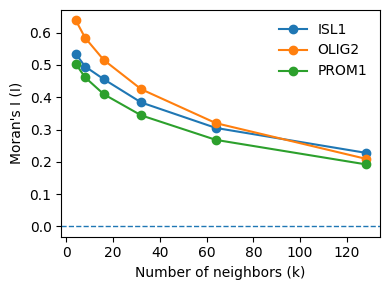

In [233]:
df = compute_knn_dependent_morans_i_gene(
    shh_test,
    genes=['OLIG2','ISL1','PROM1'],
    coord_type="generic",
    library_key='sample',
    n_neighs=[4, 8, 16, 32, 64, 128],   
    delaunay=False,
)

plot_knn_dependent_morans_i_gene(
    df,
    value_col="I",
    figsize=(4,3),
    save_path="figures/morans_knn_plot_OLIG2.png",
    dpi=300
)

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import squidpy as sq

def moran_auc(
    adata,
    genes,
    ks=(4, 8, 16, 32, 64),
    layer=None,
    use_raw=False,
    coord_type="generic",
    library_key=None,
    n_perms=None,
    transformation=True,
    plot=False,
    figsize=(6, 4),
    save=None,
    fmt=None,
    dpi=300,
):
    """
    Compute Moran's I across multiple kNN graphs and summarize each gene by
    the area under the Moran curve (AUC).

    Parameters
    ----------
    adata : AnnData
        Must contain adata.obsm["spatial"].
    genes : str or list[str]
        Gene name or list of gene names.
    ks : iterable[int]
        Numbers of neighbors used to build the spatial kNN graphs.
    layer : str or None
        Use adata.layers[layer] instead of adata.X.
    use_raw : bool
        Use adata.raw instead of adata.X.
    coord_type : str
        Passed to sq.gr.spatial_neighbors.
    library_key : str or None
        Column in adata.obs identifying slide/FOV/library.
    n_perms : int or None
        Passed to sq.gr.spatial_autocorr.
    transformation : bool
        Passed to sq.gr.spatial_autocorr.
    plot : bool
        If True, plot AUC per gene.
    figsize : tuple
        Figure size for the AUC plot.
    save : str or None
        Output path for saving the plot. If None, the plot is not saved.
    fmt : str or None
        File format for saving, e.g. "png", "pdf", "svg". If None, matplotlib
        infers it from `save`.
    dpi : int
        Resolution used when saving raster formats.

    Returns
    -------
    auc_df : pd.DataFrame
        One row per gene with AUC summary and pattern classification.
    moran_df : pd.DataFrame
        Long-format dataframe with Moran's I for each (gene, k).
    """
    if "spatial" not in adata.obsm:
        raise ValueError("adata.obsm['spatial'] is required.")

    if isinstance(genes, str):
        genes = [genes]
    genes = list(genes)

    if len(genes) == 0:
        raise ValueError("genes must contain at least one gene.")

    ks = [int(k) for k in ks]
    if len(ks) < 2 or any(k <= 0 for k in ks):
        raise ValueError("ks must contain at least two positive integers.")

    if library_key is not None and library_key not in adata.obs:
        raise ValueError(f"{library_key!r} not found in adata.obs.")

    ad = adata.copy()
    obs_keys = []

    for gene in genes:
        if use_raw:
            if ad.raw is None:
                raise ValueError("use_raw=True but adata.raw is None.")
            if gene not in ad.raw.var_names:
                raise ValueError(f"{gene!r} not found in adata.raw.var_names.")
            x = ad.raw[:, gene].X
        elif layer is not None:
            if layer not in ad.layers:
                raise ValueError(f"{layer!r} not found in adata.layers.")
            if gene not in ad.var_names:
                raise ValueError(f"{gene!r} not found in adata.var_names.")
            x = ad[:, gene].layers[layer]
        else:
            if gene not in ad.var_names:
                raise ValueError(f"{gene!r} not found in adata.var_names.")
            x = ad[:, gene].X

        if hasattr(x, "toarray"):
            x = x.toarray()
        x = np.asarray(x).reshape(-1)

        key = f"__moran_{gene}"
        ad.obs[key] = x
        obs_keys.append(key)

    rows = []

    for k in ks:
        sq.gr.spatial_neighbors(
            ad,
            n_neighs=k,
            coord_type=coord_type,
            library_key=library_key,
            delaunay=False,
        )

        sq.gr.spatial_autocorr(
            ad,
            mode="moran",
            genes=obs_keys,
            attr="obs",
            transformation=transformation,
            n_perms=n_perms,
        )

        res = ad.uns["moranI"]
        for gene, key in zip(genes, obs_keys):
            rows.append(
                {
                    "gene": gene,
                    "k": k,
                    "I": float(res.loc[key, "I"]),
                }
            )

    moran_df = pd.DataFrame(rows)

    auc_df = (
        moran_df.sort_values(["gene", "k"])
        .groupby("gene", group_keys=False)
        .apply(
            lambda g: pd.Series(
                {
                    "auc": np.trapz(g["I"].to_numpy(), g["k"].to_numpy()),
                    "auc_mean": np.trapz(g["I"].to_numpy(), g["k"].to_numpy())
                    / (g["k"].max() - g["k"].min()),
                    "I_min_k": g["I"].iloc[0],
                    "I_max_k": g["I"].iloc[-1],
                    "delta_I": g["I"].iloc[0] - g["I"].iloc[-1],
                }
            )
        )
        .reset_index()
        .sort_values("auc", ascending=False)
        .reset_index(drop=True)
    )

    x = auc_df["delta_I"]
    q25 = x.quantile(0.25)
    q75 = x.quantile(0.75)

    auc_df["pattern_delta"] = "intermediate"
    auc_df.loc[x >= q75, "pattern_delta"] = "local"
    auc_df.loc[x <= q25, "pattern_delta"] = "global"

    if plot:
        palette = {
            "global": "#27828E",
            "local": "#EE9B00",
            "intermediate": "#BDBDBD",
        }
        colors = auc_df["pattern_delta"].map(palette)

        plt.figure(figsize=figsize)
        plt.bar(auc_df["gene"], auc_df["auc"], color=colors)
        plt.ylabel("AUC of Moran's I curve")
        plt.xlabel("")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()

        if save is not None:
            plt.savefig(save, format=fmt, dpi=dpi, bbox_inches="tight")

        plt.show()

    return auc_df, moran_df

In [174]:
merged_genes = list(set(unique_local) | set(unique_global))

/tmp/ipykernel_1707975/385731534.py:146: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


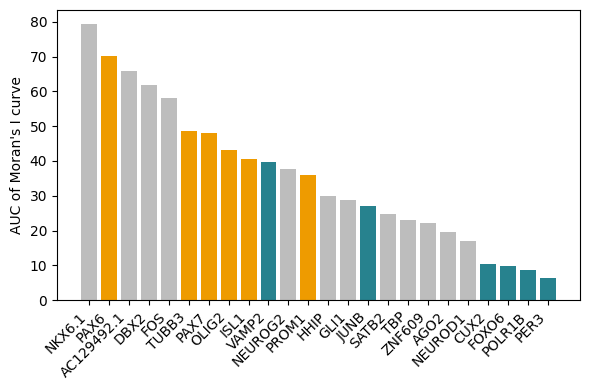

,gene,auc,auc_mean,I_min_k,I_max_k,delta_I,pattern_delta
0,NKX6.1,79.395672,0.640288,0.793129,0.541303,0.251826,intermediate
1,PAX6,70.262499,0.566633,0.782179,0.449446,0.332733,local
2,AC129492.1,65.907796,0.531514,0.641551,0.474261,0.167290,intermediate
3,DBX2,61.918914,0.499346,0.669472,0.394203,0.275268,intermediate
4,FOS,58.172010,0.469129,0.591412,0.409057,0.182355,intermediate
5,TUBB3,48.522007,0.391307,0.644160,0.285992,0.358168,local
6,PAX7,47.989902,0.387015,0.667167,0.258452,0.408715,local
7,OLIG2,43.217354,0.348527,0.638292,0.209587,0.428705,local
8,ISL1,40.652492,0.327843,0.534357,0.228013,0.306344,local
9,VAMP2,39.674256,0.319954,0.404475,0.267377,0.137098,global


In [175]:
auc_df, moran_df = moran_auc(
    shh_test,
    genes=merged_genes,
    ks=[4, 8, 16, 32, 64,128],
    library_key="sample",
    plot=True,
    save="figures/moran_auc_plot_local.png",
    fmt="png",
    dpi=300,
)

auc_df

In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import squidpy as sq


def moran_auc_ratio(
    adata,
    genes,
    ks=(4, 8, 16, 32, 64),
    layer=None,
    use_raw=False,
    coord_type="generic",
    library_key=None,
    transformation=True,
    ratio_local=0.5,
    ratio_global=0.8,
    plot=False,
    figsize=(6, 4),
    save=None,
    fmt=None,
    dpi=300,
):
    """
    Compute Moran's I across multiple kNN graphs and summarize each gene by
    the area under the Moran curve (AUC). Classification is based on the
    ratio I(k_max) / I(k_min), which captures spatial decay.

    Classification
    --------------
    ratio = I_max_k / I_min_k

    local        : ratio < ratio_local
    global       : ratio > ratio_global
    intermediate : otherwise

    Returns
    -------
    auc_df : pd.DataFrame
        One row per gene with AUC summary and ratio-based classification.
    moran_df : pd.DataFrame
        Long-format dataframe with Moran's I for each (gene, k).
    """

    if "spatial" not in adata.obsm:
        raise ValueError("adata.obsm['spatial'] is required.")

    if isinstance(genes, str):
        genes = [genes]

    ks = list(map(int, ks))
    ad = adata.copy()

    obs_keys = []

    # extract expression
    for g in genes:

        if use_raw:
            x = ad.raw[:, g].X
        elif layer is not None:
            x = ad[:, g].layers[layer]
        else:
            x = ad[:, g].X

        if hasattr(x, "toarray"):
            x = x.toarray()

        x = np.asarray(x).ravel()

        key = f"__moran_{g}"
        ad.obs[key] = x
        obs_keys.append(key)

    # build graphs once
    for k in ks:
        sq.gr.spatial_neighbors(
            ad,
            n_neighs=k,
            coord_type=coord_type,
            library_key=library_key,
            key_added=f"knn_{k}",
        )

    rows = []

    # compute Moran curves
    for k in ks:

        sq.gr.spatial_autocorr(
            ad,
            mode="moran",
            genes=obs_keys,
            attr="obs",
            connectivity_key=f"knn_{k}_connectivities",
            transformation=transformation,
        )

        res = ad.uns["moranI"]

        for g, key in zip(genes, obs_keys):

            rows.append(
                {
                    "gene": g,
                    "k": k,
                    "I": float(res.loc[key, "I"]),
                }
            )

    moran_df = pd.DataFrame(rows)

    # summarize curves
    auc_df = (
        moran_df.sort_values(["gene", "k"])
        .groupby("gene", group_keys=False)
        .apply(
            lambda g: pd.Series(
                {
                    "auc": np.trapz(g.I, g.k),
                    "auc_mean": np.trapz(g.I, g.k) / (g.k.max() - g.k.min()),
                    "I_min_k": g.I.iloc[0],
                    "I_max_k": g.I.iloc[-1],
                    "delta_I": g.I.iloc[0] - g.I.iloc[-1],
                    "ratio": g.I.iloc[-1] / g.I.iloc[0] if g.I.iloc[0] != 0 else np.nan,
                }
            )
        )
        .reset_index()
    )

    # classification
    auc_df["pattern"] = "intermediate"

    auc_df.loc[auc_df["ratio"] < ratio_local, "pattern"] = "local"
    auc_df.loc[auc_df["ratio"] > ratio_global, "pattern"] = "global"

    auc_df = auc_df.sort_values("auc", ascending=False)

    if plot:

        palette = {
            "global": "#27828E",
            "local": "#EE9B00",
            "intermediate": "#BDBDBD",
        }

        colors = auc_df.pattern.map(palette)

        plt.figure(figsize=figsize)

        plt.bar(auc_df.gene, auc_df.auc, color=colors)

        plt.ylabel("AUC of Moran curve")
        plt.xticks(rotation=45, ha="right")

        plt.tight_layout()

        if save is not None:
            plt.savefig(save, format=fmt, dpi=dpi, bbox_inches="tight")

        plt.show()

    return auc_df, moran_df

/tmp/ipykernel_1707975/4286237884.py:117: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


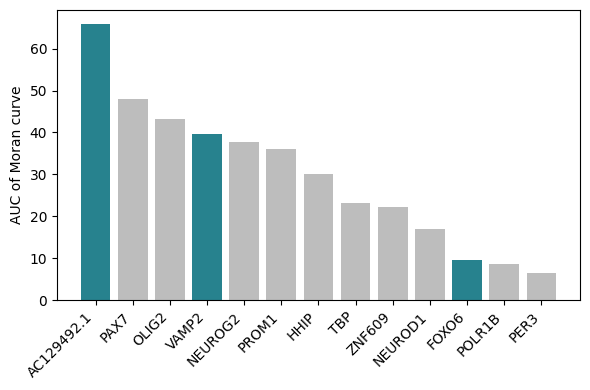

In [228]:
auc_df, moran_df = moran_auc_ratio(
    shh_test,
    genes=unique_global,#gene_set,
    ks=[4,8,16,32,64,128],
    library_key="sample",
    ratio_local=0.2,
    ratio_global=0.5,
    plot=True,
    save="figures/global_moran_auc_ratio.png",
    fmt="png",
    dpi=300,
)

/tmp/ipykernel_1707975/4286237884.py:117: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


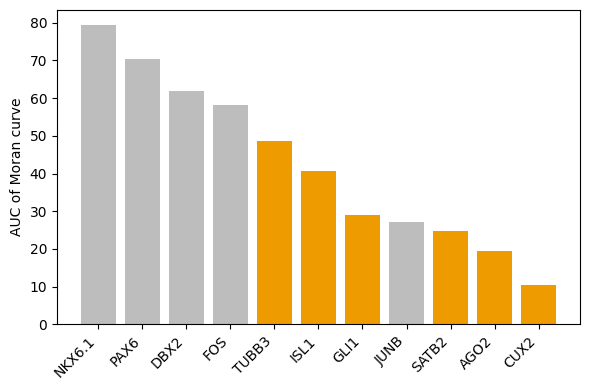

In [220]:
auc_df, moran_df = moran_auc_ratio(
    shh_test,
    genes=unique_local,#gene_set,
    ks=[4,8,16,32,64,128],
    library_key="sample",
    ratio_local=0.5,
    ratio_global=0.7,
    plot=True,
    save="figures/local_moran_auc_ratio.png",
    fmt="png",
    dpi=300,
)

/tmp/ipykernel_1707975/4286237884.py:117: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


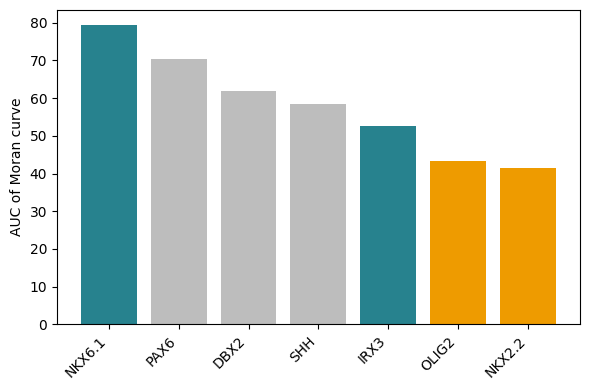

In [239]:
auc_df, moran_df = moran_auc_ratio(
    shh_test,
    genes=gene_set,#gene_set,
    ks=[4,8,16,32,64,128],
    library_key="sample",
    ratio_local=0.35,
    ratio_global=0.6,
    plot=True,
    save="figures/example_moran_auc_ratio.png",
    fmt="png",
    dpi=300,
)

In [238]:
auc_df

,gene,auc,auc_mean,I_min_k,I_max_k,delta_I,ratio,pattern
3,NKX6.1,79.395672,0.640288,0.793129,0.541303,0.251826,0.682490,global
5,PAX6,70.262499,0.566633,0.782179,0.449446,0.332733,0.574607,intermediate
0,DBX2,61.918914,0.499346,0.669472,0.394203,0.275268,0.588827,intermediate
6,SHH,58.355141,0.470606,0.704799,0.345241,0.359558,0.489843,intermediate
1,IRX3,52.667900,0.424741,0.562535,0.338197,0.224337,0.601202,global
4,OLIG2,43.217354,0.348527,0.638292,0.209587,0.428705,0.328356,intermediate
2,NKX2.2,41.548495,0.335069,0.639563,0.222049,0.417514,0.347188,intermediate


In [125]:
import gseapy as gp

In [126]:
enr_global = gp.enrichr(
    gene_list=unique_global.tolist(),
    gene_sets="GO_Biological_Process_2025",
    organism="Human",   # or "Mouse"
    outdir=None,
)
enr_global.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Sensory Organ Development (GO:0007423),3/74,0.000014,0.002031,0,0,84.152113,943.331604,NEUROD1;OLIG2;NEUROG2
1,GO_Biological_Process_2025,Axon Development (GO:0061564),3/107,0.000041,0.003071,0,0,57.354808,579.466236,NEUROD1;OLIG2;NEUROG2
2,GO_Biological_Process_2025,Response to Hexose (GO:0009746),2/25,0.000116,0.005801,0,0,157.818182,1430.110648,NEUROD1;VAMP2
3,GO_Biological_Process_2025,Regulation of Transcription by RNA Polymerase ...,7/2250,0.000209,0.007135,0,0,9.229306,78.184400,NEUROD1;ZNF609;PER3;PAX7;FOXO6;OLIG2;NEUROG2
4,GO_Biological_Process_2025,Positive Regulation of Transcription by RNA Po...,5/983,0.000262,0.007135,0,0,12.147878,100.165825,NEUROD1;ZNF609;TBP;OLIG2;NEUROG2


In [127]:
enr_local = gp.enrichr(
    gene_list=unique_local.tolist(),
    gene_sets="GO_Biological_Process_2025",
    organism="Human",   # or "Mouse"
    outdir=None,
)
enr_local.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Regulation of Transcription by RNA Polymerase ...,8/2250,0.000003,0.000526,0,0,21.108534,268.040180,CUX2;SATB2;AGO2;DBX2;PAX6;FOS;GLI1;ISL1
1,GO_Biological_Process_2025,Positive Regulation of Transcription by RNA Po...,6/983,0.000005,0.000526,0,0,23.351484,284.184432,SATB2;AGO2;PAX6;FOS;GLI1;ISL1
2,GO_Biological_Process_2025,Positive Regulation of DNA-templated Transcrip...,6/1274,0.000023,0.001563,0,0,17.717035,189.142602,SATB2;AGO2;PAX6;FOS;GLI1;ISL1
3,GO_Biological_Process_2025,Neuron Fate Commitment (GO:0048663),2/16,0.000033,0.001668,0,0,317.063492,3273.111441,PAX6;ISL1
4,GO_Biological_Process_2025,Positive Regulation of miRNA Transcription (GO...,2/47,0.000293,0.011908,0,0,98.488889,801.141933,PAX6;FOS


In [128]:
df_local = enr_local.results
df_global = enr_global.results

In [140]:
top_local = df_local.sort_values("Adjusted P-value").head(6)
top_global = df_global.sort_values("Adjusted P-value").head(6)

In [141]:
df_local["group"] = "Local"
df_global["group"] = "Global"

combined = pd.concat([
    df_local.sort_values("Adjusted P-value").head(6),
    df_global.sort_values("Adjusted P-value").head(6)
])

combined["-log10(padj)"] = -np.log10(combined["Adjusted P-value"])

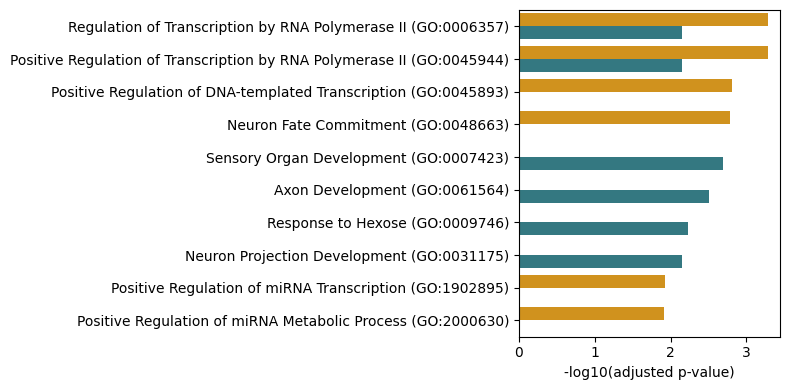

In [143]:
import seaborn as sns

combined = combined.sort_values("-log10(padj)", ascending=False)

palette = {
    "Global": "#27828E",
    "Local": "#EE9B00"
}

plt.figure(figsize=(8,4))

sns.barplot(
    data=combined,
    y="Term",
    x="-log10(padj)",
    hue="group",
    palette=palette,
    legend=False
)

plt.xlabel("-log10(adjusted p-value)", fontsize=10)
plt.ylabel("", fontsize=10)
#plt.title("GO enrichment: global vs local embeddings", fontsize=10)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

#plt.legend(title="", fontsize=10)

plt.tight_layout()
plt.savefig("figures/gene_programs.png", dpi=300, bbox_inches="tight")
plt.show()

##### 4. Moran's I for selected embedding dimensions across multiple spatial radii.

### Gene rank analysis

In [145]:
shh_test.layers['_y_pred_local']

array([[-0.41784543,  0.10436597,  0.15581939, ..., -0.439008  ,
        -0.8869709 , -0.24236163],
       [-0.18968302, -0.21860307, -0.188813  , ..., -0.93693584,
        -0.8444304 , -0.01079343],
       [-0.2361882 ,  0.70588744,  0.231318  , ...,  0.16956502,
        -1.0536482 ,  0.4068437 ],
       ...,
       [-0.27271843, -0.07589218, -0.2681569 , ..., -0.6622197 ,
        -0.46413535, -0.08217128],
       [-0.40162152,  0.41832587, -0.07500255, ..., -0.27980423,
        -1.0338154 , -0.17561972],
       [-0.456762  ,  0.09235121, -0.21919376, ..., -0.6240566 ,
        -0.7109809 , -0.25395873]], dtype=float32)

/ictstr01/groups/ml01/workspace/sara.jimenez/InterScale/GT-long-range-niches/src/InterScale/evaluation/gene_rank_analysis.py:42: RuntimeWarning: invalid value encountered in log1p
  r2_scores_log = [np.log1p(r2) if not np.isnan(r2) else np.nan for r2 in r2_scores]
/ictstr01/groups/ml01/workspace/sara.jimenez/InterScale/GT-long-range-niches/src/InterScale/evaluation/gene_rank_analysis.py:42: RuntimeWarning: invalid value encountered in log1p
  r2_scores_log = [np.log1p(r2) if not np.isnan(r2) else np.nan for r2 in r2_scores]


Top 7 genes for _y_pred_local model:
       gene        r2    r2_log  r2_rank
26   FOXA2  0.182744  0.167837     88.0
61   OLIG2  0.146233  0.136481     87.0
36    HHIP  0.133097  0.124955     86.0
39    IRX3  0.018393  0.018226     85.0
53  NKX2.1  0.000000  0.000000     82.5
74    SIX6  0.000000  0.000000     82.5
86   FOXG1  0.000000  0.000000     82.5
Top 7 genes for _y_pred_global model:
       gene        r2    r2_log  r2_rank
53  NKX2.1  0.000000  0.000000     86.5
74    SIX6  0.000000  0.000000     86.5
86   FOXG1  0.000000  0.000000     86.5
87   TREM2  0.000000  0.000000     86.5
22     FOS -0.018821 -0.019000     84.0
41     JUN -0.067203 -0.069568     83.0
61   OLIG2 -0.084540 -0.088328     82.0


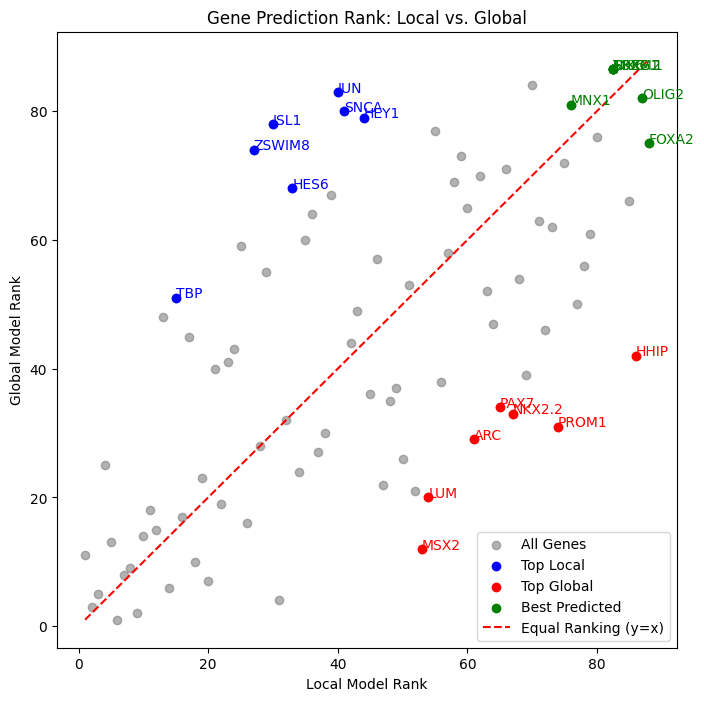

(      gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 40    ISL1        30.0         78.0            -48.0      54.0
 85  ZSWIM8        27.0         74.0            -47.0      50.5
 41     JUN        40.0         83.0            -43.0      61.5
 76    SNCA        41.0         80.0            -39.0      60.5
 79     TBP        15.0         51.0            -36.0      33.0
 34    HES6        33.0         68.0            -35.0      50.5
 35    HEY1        44.0         79.0            -35.0      61.5,
       gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 36    HHIP        86.0         42.0             44.0      64.0
 69   PROM1        74.0         31.0             43.0      52.5
 49    MSX2        53.0         12.0             41.0      32.5
 45     LUM        54.0         20.0             34.0      37.0
 54  NKX2.2        67.0         33.0             34.0      50.0
 5      ARC        61.0         29.0             32.0      45.0
 65    PAX7        65.0         34.0   

In [232]:
from InterScale.evaluation.gene_rank_analysis import predict_gene_r2, gene_rank_analysis

gene_rank_analysis(
    shh_test,
    layers_local_pred="_y_pred_local",
    layers_global_pred="_y_pred_global",
    top_n=7,
    plot_result=True,
    return_top_genes=True,
)

In [31]:
gene_name = 'SHH'
threshold = 3.5 # can depend on the slide? 

if gene_name in result.var_names:
    gene_expression = result[:, gene_name].X
    if not isinstance(gene_expression, np.ndarray):
        gene_expression = gene_expression.toarray().flatten()  # For sparse matrices
    else:
        gene_expression = gene_expression.flatten()

    # Annotate cells in the obs field based on the expression threshold
    result.obs[f'{gene_name}_status'] = np.where(gene_expression >= threshold, f'{gene_name}+', f'{gene_name}-')
else:
    print(f"Gene '{gene_name}' not found in adata.var_names.")

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


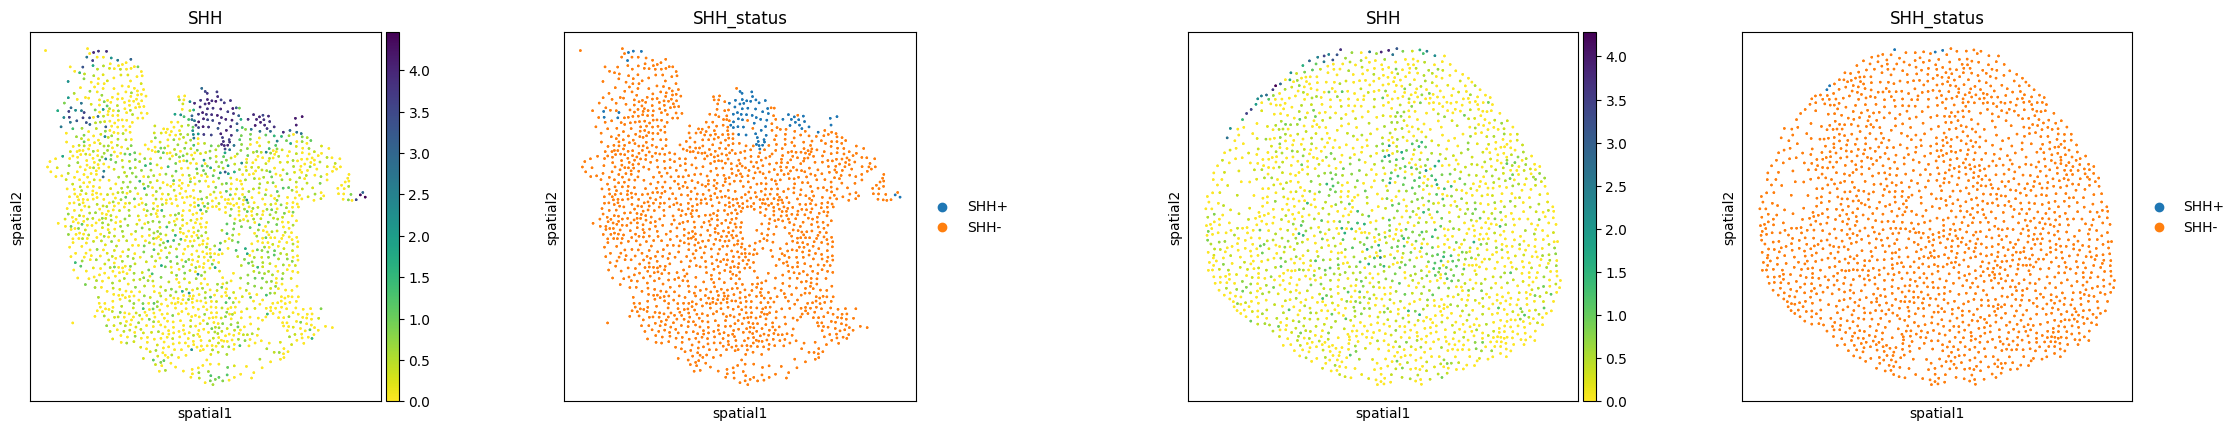

In [32]:
sq.pl.spatial_scatter(result, 
                      library_key='sample',
                      library_id=['slide4_B2-2','slide4_A2-3'],
                      color = ['SHH','SHH_status'],
                      cmap = 'viridis_r',
                      shape= None
                     )

In [48]:
# Coordinates
coords = result.obsm["spatial"]
shh_coords = coords[result.obs["SHH_status"] == "SHH+"]

# Compute distance to nearest SHH+ cell
from scipy.spatial import cKDTree
tree = cKDTree(shh_coords)
dist, _ = tree.query(coords, k=1)
result.obs["dist_to_SHH+"] = dist

# Cluster cells based on distance
sc.pp.neighbors(result, use_rep=None, n_neighbors=10)
result.obs["distance_cluster"] = np.digitize(result.obs["dist_to_SHH+"], bins=[10, 20, 30])  # arbitrary cutoffs

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 88 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


In [ ]:
# Coordinates
coords = ctrl_test.obsm["spatial"]
shh_coords = coords[ctrl_test.obs["SHH_status"] == "SHH+"]

# Compute distance to nearest SHH+ cell
from scipy.spatial import cKDTree
tree = cKDTree(shh_coords)
dist, _ = tree.query(coords, k=1)
ctrl_test.obs["dist_to_SHH+"] = dist

# Cluster cells based on distance
sc.pp.neighbors(ctrl_test, use_rep=None, n_neighbors=10)
ctrl_test.obs["distance_cluster"] = np.digitize(ctrl_test.obs["dist_to_SHH+"], bins=[10, 20, 30])  # arbitrary cutoffs

In [49]:
dist = result.obs["dist_to_SHH+"].to_numpy()

n_bins = 5
edges = np.quantile(dist, np.linspace(0, 1, n_bins + 1))
labels = [f"ring_{i+1}" for i in range(len(edges)-1)]

cats = pd.cut(dist, bins=edges, labels=labels, include_lowest=True, duplicates="drop")
# directly ensure it's ordered
cats = pd.Categorical(cats, categories=labels, ordered=True)

result.obs["SHH_dist_ring"] = cats

In [ ]:
dist = ctrl_test.obs["dist_to_SHH+"].to_numpy()

n_bins = 5
edges = np.quantile(dist, np.linspace(0, 1, n_bins + 1))
labels = [f"ring_{i+1}" for i in range(len(edges)-1)]

cats = pd.cut(dist, bins=edges, labels=labels, include_lowest=True, duplicates="drop")
# directly ensure it's ordered
cats = pd.Categorical(cats, categories=labels, ordered=True)

ctrl_test.obs["SHH_dist_ring"] = cats

In [51]:
result.uns['SHH_dist_ring_colors'] = ['#556FA7','#C62A22','#7A81FF','#679B36','#E38236']

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


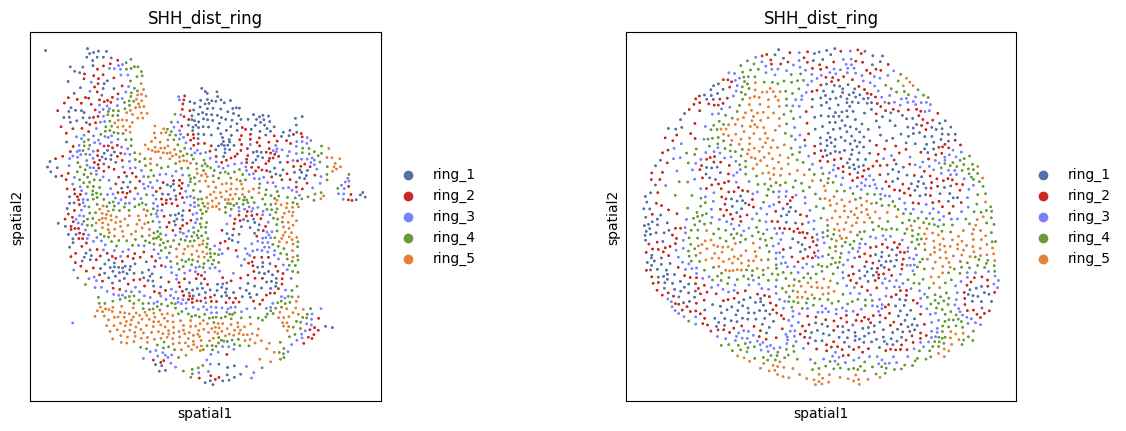

In [52]:
sq.pl.spatial_scatter(result, 
                      library_key='sample',
                      library_id=['slide4_B2-2','slide4_A2-3'],
                      color = ['SHH_dist_ring'],
                      #cmap = 'viridis_r',
                      shape= None
                     )

In [ ]:
sc.pl.dotplot(ctrl_test, var_names=unique_global, groupby='SHH_dist_ring', standard_scale='var', cmap='BrBG_r')

In [ ]:
sc.pl.dotplot(ctrl_test, var_names=unique_local, groupby='SHH_dist_ring', standard_scale='var', cmap='BrBG_r')

In [ ]:
rings = ctrl_test.obs["SHH_dist_ring"].astype("category")
emb = ctrl_test.obsm["_local_emb"]  # shape: (n_cells, d)
d = emb.shape[1]

# --- make a DataFrame for easy grouping
#cols = [f"dim_{i+1}" for i in range(d)]
cols = [f"dim_{i}" for i in range(d)]
df = pd.DataFrame(emb, columns=cols)
df["ring"] = rings.values

# ensure ordered rows by categorical order
ordered_rings = list(rings.cat.categories)

# --- aggregate: mean per ring (you can swap to .median() if you prefer)
M = (df.groupby("ring")[cols]
       .mean()
       .reindex(ordered_rings))

# --- optional: z-score each column so colors are comparable across dims
# comment this block if you prefer raw means
M = (M - M.mean(axis=0)) / (M.std(axis=0).replace(0, np.nan))
M = M.fillna(0.0)

# --- plot with matplotlib
fig_h = 0.6 * len(ordered_rings) + 2
fig_w = min(0.45 * d + 3, 18)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

im = ax.imshow(M.values, aspect="auto", interpolation="nearest")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Embedding (z-score)")

# ticks/labels
ax.set_yticks(range(len(ordered_rings)))
ax.set_yticklabels(ordered_rings)

# For many dims, thin x tick labels
step = 1 if d <= 30 else (2 if d <= 60 else 5)
ax.set_xticks(range(0, d, step))
ax.set_xticklabels([cols[i] for i in range(0, d, step)], rotation=90)

ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Distance-based cluster (rings)")
ax.set_title("Local embedding by SHH distance rings")

plt.tight_layout()
plt.show()

In [33]:
result.obs['condition'].cat.categories

Index(['Ctrl', 'SHH'], dtype='object')

In [34]:
sq.tl.var_by_distance(
    adata=result,
    groups="SHH+",
    cluster_key="SHH_status",
    library_key="sample",
    #library_id='slide4_B2-2'
    covariates=["condition"],
)

In [38]:
result

AnnData object with n_obs × n_vars = 43114 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_label', '_cls_horizontal', '_cls_vertical', 'z11_global', 'z5_global', 'z1_global', 'z7_global', 'z10_global', 'z13_local', 'z1_local', 'z14_local', 'z7_local', 'z0_local', 'z2_local', 'SHH_status'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'SHH_status_colors', 'condition_colors'
    obsm: 'spatial', '_local_emb', '_global_emb', '_attn_matrix', 'design_matrix'
    varm: '_local_std_gene_loadings', '_global_std_gene_loadings'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', '_y_pred_local', '_y_pred_global'

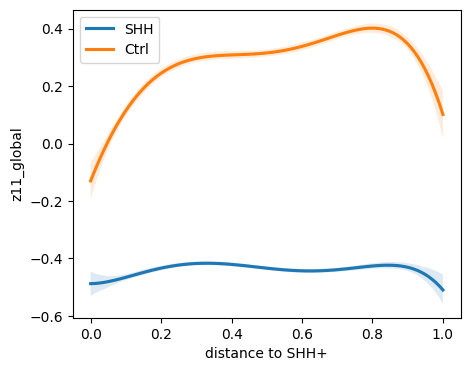

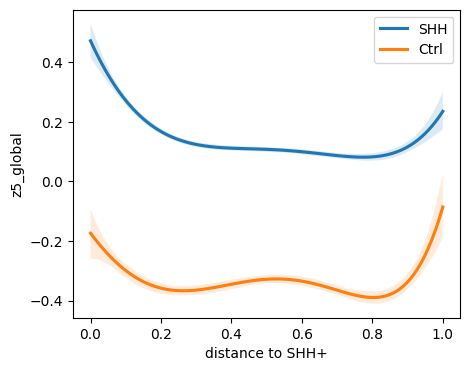

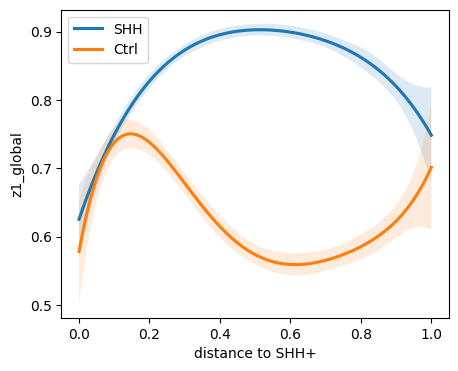

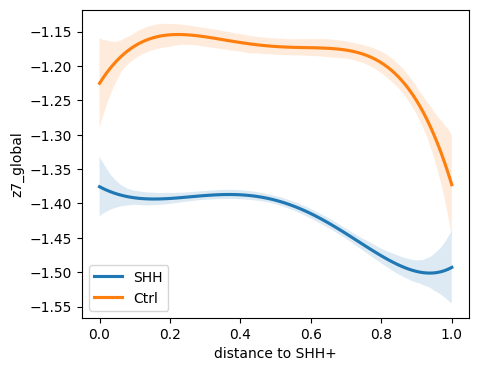

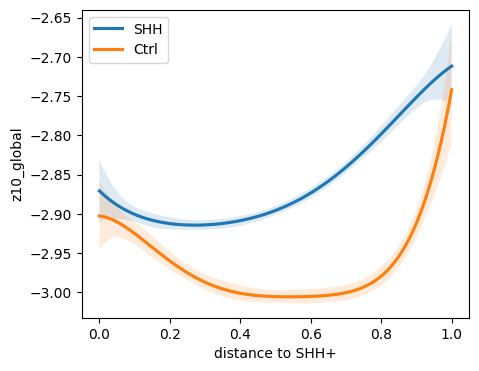

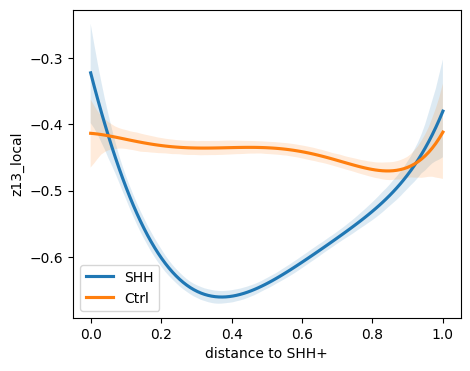

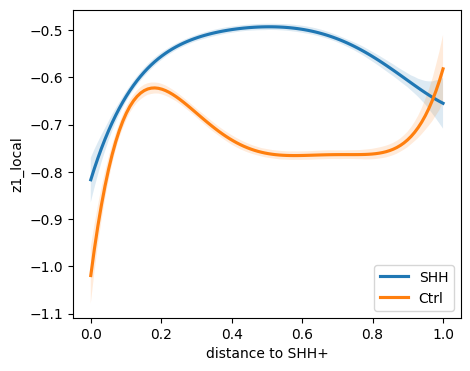

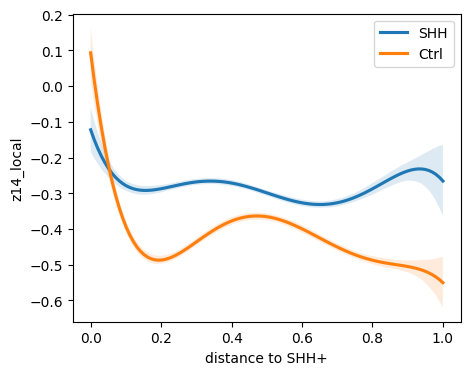

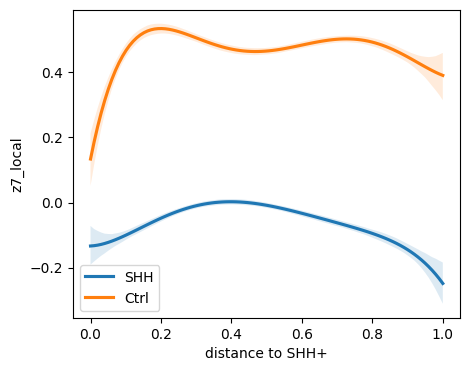

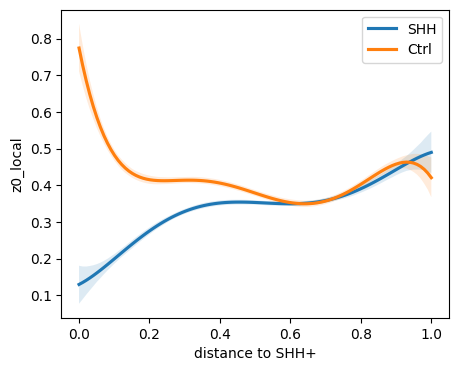

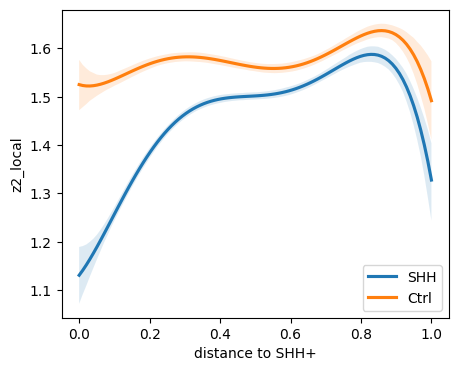

In [39]:
to_plot = ['z11_global', 'z5_global', 'z1_global', 'z7_global', 'z10_global', 'z13_local', 'z1_local', 'z14_local', 'z7_local', 'z0_local', 'z2_local']

for var2plot in to_plot:
    sq.pl.var_by_distance(
        adata=result,
        design_matrix_key="design_matrix",
        var=var2plot,
        #stack_vars=True,
        anchor_key="SHH+",
        covariate="condition",
        #line_palette=["blue", "orange"],
        show_scatter=False,
        figsize=(5, 4),
    )